In [1]:
import sys
import os

# Add the folder and subfolder to the system path
sys.path.append(os.path.abspath(os.path.join('../../../')))

# Now you can import your module
# from your_module import your_function

# Inport data from geopandas

In [2]:
import numpy as np
import pandas as pd

parent_dir = "/home/biazzin/git/mimesis/data/ourdata/copernicus_ecdc/"
parent_dir = "../data/"
year = "2020"
df = pd.read_csv(parent_dir + f'albopictus_presence_absence_ecdc_world_clim_all_bio.zip')
#df_suitable = df[df['Suitable'] == 1]  # Select only the suitable records
df_suitable = df


In [3]:
df_suitable.columns

Index(['Longitude', 'Latitude', 'Presence_Absence', 'NUTS3_Code', 'TAVG_01',
       'TAVG_02', 'TAVG_03', 'TAVG_04', 'TAVG_05', 'TAVG_06', 'TAVG_07',
       'TAVG_08', 'TAVG_09', 'TAVG_10', 'TAVG_11', 'TAVG_12', 'annual_temp',
       'BIO_2', 'BIO_3', 'BIO_4', 'max_temp_warmest_month', 'BIO_6', 'BIO_7',
       'BIO_8', 'BIO_9', 'BIO_10', 'BIO_11', 'annual_prec', 'BIO_13', 'BIO_14',
       'BIO_15', 'BIO_16', 'BIO_17', 'prec_warmest_quarter',
       'Temperature Suitable', 'Precipitation Suitable', 'Suitable'],
      dtype='object')

In [4]:
df_suitable["presence_numeric"] = df_suitable["Presence_Absence"]

In [5]:
df_suitable

,Longitude,Latitude,Presence_Absence,NUTS3_Code,TAVG_01,TAVG_02,TAVG_03,TAVG_04,TAVG_05,TAVG_06,...,BIO_13,BIO_14,BIO_15,BIO_16,BIO_17,prec_warmest_quarter,Temperature Suitable,Precipitation Suitable,Suitable,presence_numeric
0,19.087500,74.512500,0,NO0B2,-7.2,-7.3,-6.2,-5.0,-1.1,2.3,...,47.0,19.0,24.667305,125.0,66.0,103.0,False,True,False,0
1,18.937500,74.504167,0,NO0B2,-7.2,-7.3,-6.2,-4.9,-1.0,2.3,...,47.0,19.0,25.584385,125.0,64.0,101.0,False,True,False,0
2,18.954167,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-5.0,-1.0,2.3,...,47.0,19.0,25.584385,125.0,64.0,101.0,False,True,False,0
3,18.962500,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-4.9,-1.0,2.3,...,47.0,19.0,25.464890,125.0,64.0,101.0,False,True,False,0
4,18.970833,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-5.0,-1.0,2.3,...,47.0,19.0,25.396273,125.0,64.0,101.0,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11259760,32.937500,34.570833,2,CY00,12.4,12.7,14.2,17.4,20.6,24.2,...,91.0,0.0,101.227264,240.0,4.0,4.0,True,True,True,2
11259761,32.945833,34.570833,2,CY00,12.4,12.6,14.2,17.3,20.6,24.2,...,91.0,0.0,101.227264,240.0,4.0,4.0,True,True,True,2
11259762,32.954167,34.570833,2,CY00,12.4,12.6,14.2,17.3,20.6,24.2,...,91.0,0.0,101.586970,240.0,4.0,4.0,True,True,True,2
11259763,32.962500,34.570833,2,CY00,12.4,12.6,14.2,17.4,20.7,24.2,...,91.0,0.0,101.586970,240.0,4.0,4.0,True,True,True,2


In [6]:
df_Presence_Absence = (df_suitable[(df_suitable["presence_numeric"] == 1) | (df_suitable["presence_numeric"] == 0)]).copy()

In [7]:
# set presence absence to 1 if suitable is 1, otherwise set to 0
df_Presence_Absence["Presence_Absence"] = ((df_Presence_Absence['presence_numeric'] == 1) & (df_Presence_Absence['Suitable'] == 1)).astype(int)

# Check data and remove points set as absence close to points set as presence

<Axes: >

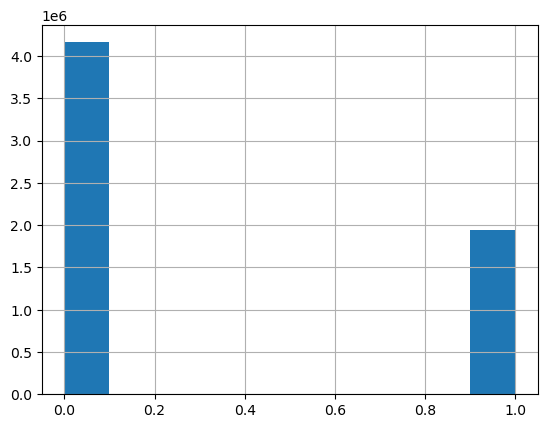

In [8]:
import matplotlib.pyplot as plt
df_Presence_Absence["Presence_Absence"].hist()

In [9]:
df_Presence_Absence.columns

Index(['Longitude', 'Latitude', 'Presence_Absence', 'NUTS3_Code', 'TAVG_01',
       'TAVG_02', 'TAVG_03', 'TAVG_04', 'TAVG_05', 'TAVG_06', 'TAVG_07',
       'TAVG_08', 'TAVG_09', 'TAVG_10', 'TAVG_11', 'TAVG_12', 'annual_temp',
       'BIO_2', 'BIO_3', 'BIO_4', 'max_temp_warmest_month', 'BIO_6', 'BIO_7',
       'BIO_8', 'BIO_9', 'BIO_10', 'BIO_11', 'annual_prec', 'BIO_13', 'BIO_14',
       'BIO_15', 'BIO_16', 'BIO_17', 'prec_warmest_quarter',
       'Temperature Suitable', 'Precipitation Suitable', 'Suitable',
       'presence_numeric'],
      dtype='object')

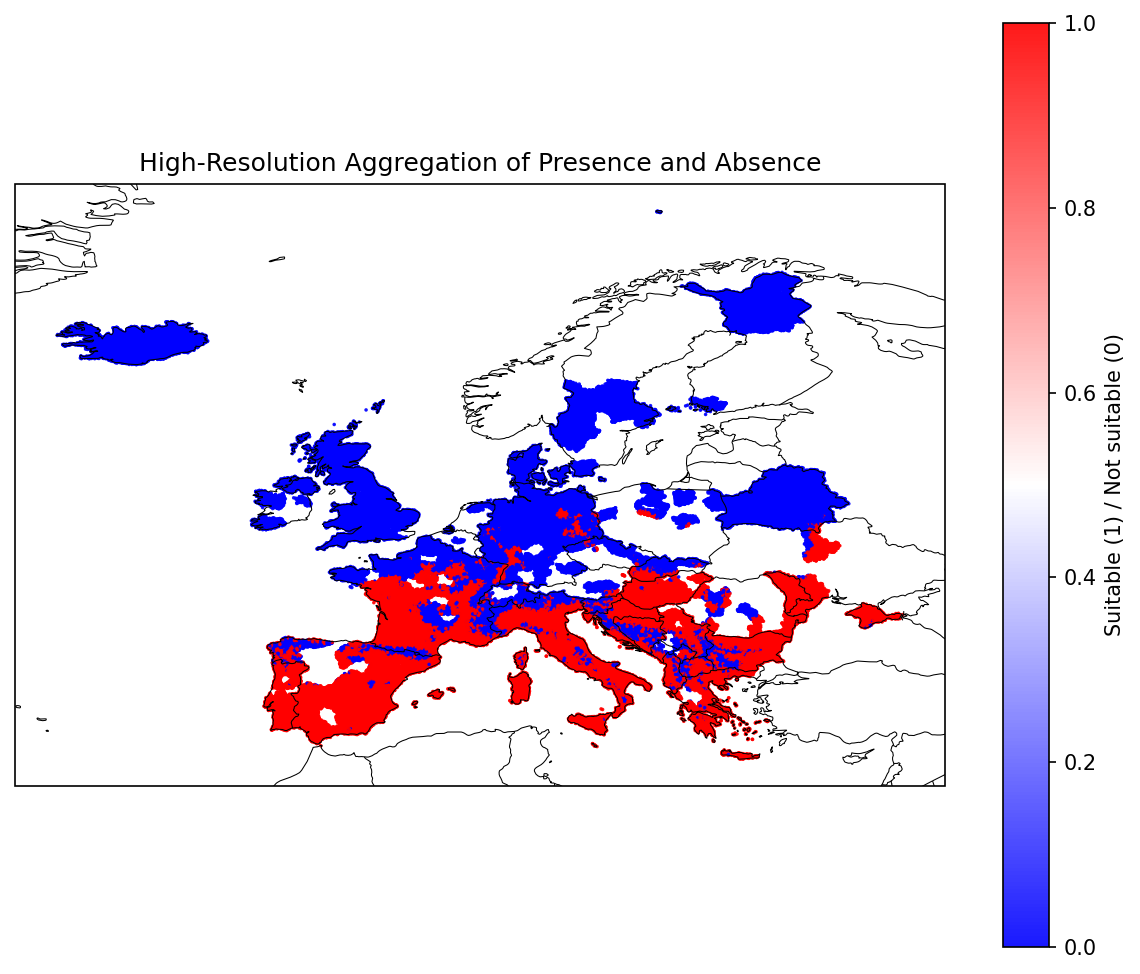

In [10]:

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create a figure with a cartographic projection
fig = plt.figure(figsize=(10, 8), dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())
df_Presence_Absence_sampled = df_Presence_Absence.sample(n=100000, random_state=1)
# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Plot the data
sc = ax.scatter(
    df_Presence_Absence_sampled['Longitude'],
    df_Presence_Absence_sampled['Latitude'],
    c=df_Presence_Absence_sampled['Suitable'],
    cmap='bwr',
    s=0.5,
    alpha=0.9,
    transform=ccrs.PlateCarree()
)

# Add a colorbar and titles
plt.colorbar(sc, label='Suitable (1) / Not suitable (0)')
plt.title('High-Resolution Aggregation of Presence and Absence')
plt.show()

In [11]:
import geopandas as gpd

df_gdf = gpd.GeoDataFrame(df_Presence_Absence, geometry=gpd.points_from_xy(df_Presence_Absence['Longitude'], df_Presence_Absence['Latitude']))

<Axes: >

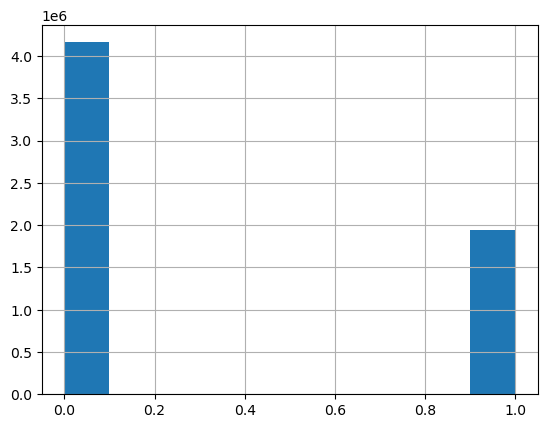

In [12]:
df_Presence_Absence = df_gdf.copy()

df_Presence_Absence["Presence_Absence"].hist()

In [13]:
import AIedes.data_loader.classificator_data_loader
import importlib

from AIedes.data_loader.classificator_data_loader import normalize_temperature_df, normalize_precipitation_df

#df_Presence_Absence = normalize_temperature_df(df_Presence_Absence)
#df_Presence_Absence = normalize_precipitation_df(df_Presence_Absence)

In [14]:
df_Presence_Absence

,Longitude,Latitude,Presence_Absence,NUTS3_Code,TAVG_01,TAVG_02,TAVG_03,TAVG_04,TAVG_05,TAVG_06,...,BIO_14,BIO_15,BIO_16,BIO_17,prec_warmest_quarter,Temperature Suitable,Precipitation Suitable,Suitable,presence_numeric,geometry
0,19.087500,74.512500,0,NO0B2,-7.2,-7.3,-6.2,-5.0,-1.1,2.3,...,19.0,24.667305,125.0,66.0,103.0,False,True,False,0,POINT (19.0875 74.5125)
1,18.937500,74.504167,0,NO0B2,-7.2,-7.3,-6.2,-4.9,-1.0,2.3,...,19.0,25.584385,125.0,64.0,101.0,False,True,False,0,POINT (18.9375 74.50417)
2,18.954167,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-5.0,-1.0,2.3,...,19.0,25.584385,125.0,64.0,101.0,False,True,False,0,POINT (18.95417 74.50417)
3,18.962500,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-4.9,-1.0,2.3,...,19.0,25.464890,125.0,64.0,101.0,False,True,False,0,POINT (18.9625 74.50417)
4,18.970833,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-5.0,-1.0,2.3,...,19.0,25.396273,125.0,64.0,101.0,False,True,False,0,POINT (18.97083 74.50417)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11257580,24.112500,34.820833,1,EL434,12.4,12.2,13.3,16.1,19.6,23.6,...,1.0,89.452310,295.0,5.0,5.0,True,True,True,1,POINT (24.1125 34.82083)
11257727,24.104167,34.812500,1,EL434,12.2,12.1,13.2,16.0,19.6,23.6,...,1.0,89.652730,299.0,5.0,5.0,True,True,True,1,POINT (24.10417 34.8125)
11257728,24.112500,34.812500,1,EL434,12.4,12.2,13.3,16.0,19.6,23.6,...,1.0,89.654280,297.0,5.0,5.0,True,True,True,1,POINT (24.1125 34.8125)
11257729,24.120833,34.812500,1,EL434,12.7,12.5,13.5,16.3,19.8,23.7,...,1.0,90.201190,289.0,4.0,4.0,True,True,True,1,POINT (24.12083 34.8125)


In [15]:
df_gdf.shape[0]

6098760

In [16]:
features_temp_tp = ['TAVG_01', 'TAVG_02', 'TAVG_03', 'TAVG_04', 'TAVG_05', 'TAVG_06', 'TAVG_07', 
                    'TAVG_08', 'TAVG_09', 'TAVG_10', 'TAVG_11', 'TAVG_12',
                    'annual_temp', 'annual_prec']
features_4Bio = ['annual_temp', 'annual_prec', 'max_temp_warmest_month', 'prec_warmest_quarter']
datas = {}
df_years = {}

data_temp_tp = df_Presence_Absence[features_temp_tp + ["Presence_Absence"]].to_numpy()
data_4Bio = df_Presence_Absence[features_4Bio + ["Presence_Absence"]].to_numpy()

In [17]:
import importlib
import torch
# set threads to 1 to avoid issues with multiprocessing in Jupyter notebooks
torch.set_num_threads(4)
# set number of cpu threads to 1 to avoid issues with multiprocessing in Jupyter notebooks
#torch.set_num_interop_threads(4)

In [18]:
import importlib
from locale import normalize
from AIedes.data_loader.classificator_data_loader import get_data_loaders
# Get data loaders and input size
batch_size = 1024
learning_rate = 0.002
random_seed = 42

train_loaders = {}
test_loaders = {}
train_loader_order_temp_tp, test_loader_order_temp_tp, input_size_order_temp_tp, _ = get_data_loaders(
    data=data_temp_tp, batch_size = batch_size, test_ratio = 1, random_seed = random_seed, shuffle = False, normalize=True
)
train_loader_order_4Bio, test_loader_order_4Bio, input_size_order_4Bio, _ = get_data_loaders(
    data=data_4Bio, batch_size = batch_size, test_ratio = 1, random_seed = random_seed, shuffle = False, normalize=False
)
train_loader_order_4Bio_nn, test_loader_order_4Bio_nn, input_size_order_4Bio_nn, _ = get_data_loaders(
    data=data_4Bio, batch_size = batch_size, test_ratio = 1, random_seed = random_seed, shuffle = False, normalize=True
)



/home/biazzin/git/AIedes/src/AIedes/data_loader/classificator_data_loader.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.float)  # Labels for classification


In [19]:
data_4Bio

array([[ -1.8791667, 405.       ,   6.8      , 103.       ,   0.       ],
       [ -1.85     , 402.       ,   6.9      , 101.       ,   0.       ],
       [ -1.8541666, 402.       ,   6.9      , 101.       ,   0.       ],
       ...,
       [ 18.558334 , 538.       ,  29.1      ,   5.       ,   1.       ],
       [ 18.783333 , 522.       ,  29.       ,   4.       ,   1.       ],
       [ 18.9875   , 507.       ,  29.2      ,  15.       ,   1.       ]],
      shape=(6098760, 5))

# Function like the paper

In [20]:
import pandas as pd
import pickle
from AIedes.train.classificator_train    import run_model
from AIedes.evaluation.classificator_evaluate import evaluate_model_nuts3, evaluate_model

# read all the result and models files that have "temp_tp" in the name
# list in the current directory that have "temp_tp" in the name
import glob
results_files_temp_tp = glob.glob("../results/results_and_models*temp_tp.pkl")
print("Results files found:", results_files_temp_tp)
res_df = []
for name_file in results_files_temp_tp:
    print("Loading file:", name_file)
    with open(name_file, 'rb') as f:
        results = pickle.load(f)
    #print("Results loaded:", results)
    res_df.append(results)
res_df = pd.concat(res_df, ignore_index=True)
results_files_4Bio = glob.glob("../results/results_and_models*4Bio.pkl")
print("Results files found:", results_files_4Bio)
res_df_4Bio = []
for name_file in results_files_4Bio:
    print("Loading file:", name_file)
    with open(name_file, 'rb') as f:
        results = pickle.load(f)
    #print("Results loaded:", results)
    res_df_4Bio.append(results)
res_df_4Bio = pd.concat(res_df_4Bio, ignore_index=True)
res_df_4Bio["input"] = "4Bio"
res_df["input"] = "temp_tp"
res_df = pd.concat([res_df, res_df_4Bio], ignore_index=True)

Results files found: ['../results/results_and_models_2020_[]_temp_tp.pkl', '../results/results_and_models_2020_[10]_temp_tp.pkl', '../results/results_and_models_2020_[30]_temp_tp.pkl', '../results/results_and_models_2020_[10, 10]_temp_tp.pkl', '../results/results_and_models_2020_[30, 30]_temp_tp.pkl', '../results/results_and_models_2020_[10, 10, 10]_temp_tp.pkl', '../results/results_and_models_2020_[30, 30, 30]_temp_tp.pkl', '../results/results_and_models_2020_[40, 40]_temp_tp.pkl', '../results/results_and_models_2020_[40, 40, 40]_temp_tp.pkl']
Loading file: ../results/results_and_models_2020_[]_temp_tp.pkl
Loading file: ../results/results_and_models_2020_[10]_temp_tp.pkl
Loading file: ../results/results_and_models_2020_[30]_temp_tp.pkl
Loading file: ../results/results_and_models_2020_[10, 10]_temp_tp.pkl
Loading file: ../results/results_and_models_2020_[30, 30]_temp_tp.pkl
Loading file: ../results/results_and_models_2020_[10, 10, 10]_temp_tp.pkl
Loading file: ../results/results_and_mo

In [21]:
res_df

,hidden_layers,ACC_test_list,TPR_test_list,TNR_test_list,FPR_test_list,FNR_test_list,MEAN_ACC_test,MEAN_TPR_test,MEAN_TNR_test,MEAN_FPR_test,...,num_params,num_epochs,test_ratio,val_ratio,learning_rate,random_seed,input_variables,input_size,model,input
0,[],[89.10659717464411],[0.8254192250141892],[0.9219531024303321],[0.07804689756966782],[0.17458077498581084],89.106597,0.825419,0.921953,0.078047,...,15,100,0.2,0.0,0.005,42,"[TAVG_01, TAVG_02, TAVG_03, TAVG_04, TAVG_05, ...",14,[AIedesClassificator(\n (layers): ModuleList(...,temp_tp
1,[10],[95.16937442321566],[0.9462360043341417],[0.9542616388173403],[0.0457383611826597],[0.053763995665858315],95.169374,0.946236,0.954262,0.045738,...,161,100,0.2,0.0,0.005,42,"[TAVG_01, TAVG_02, TAVG_03, TAVG_04, TAVG_05, ...",14,[AIedesClassificator(\n (layers): ModuleList(...,temp_tp
2,[30],[97.54906897308862],[0.9619188896341778],[0.9818762912125928],[0.018123708787407232],[0.0380811103658222],97.549069,0.961919,0.981876,0.018124,...,481,100,0.2,0.0,0.005,42,"[TAVG_01, TAVG_02, TAVG_03, TAVG_04, TAVG_05, ...",14,[AIedesClassificator(\n (layers): ModuleList(...,temp_tp
3,"[10, 10]",[97.2364704347984],[0.9581110365822197],[0.9790711280615849],[0.020928871938415076],[0.0418889634177803],97.236470,0.958111,0.979071,0.020929,...,271,100,0.2,0.0,0.005,42,"[TAVG_01, TAVG_02, TAVG_03, TAVG_04, TAVG_05, ...",14,[AIedesClassificator(\n (layers): ModuleList(...,temp_tp
4,"[30, 30]",[98.75761272780402],[0.9842165006965585],[0.9891568487979433],[0.010843151202056716],[0.015783499303441514],98.757613,0.984217,0.989157,0.010843,...,1411,100,0.2,0.0,0.005,42,"[TAVG_01, TAVG_02, TAVG_03, TAVG_04, TAVG_05, ...",14,[AIedesClassificator(\n (layers): ModuleList(...,temp_tp
5,"[10, 10, 10]",[97.71770874433946],[0.954955884629276],[0.9876322772195505],[0.012367722780449555],[0.045044115370723906],97.717709,0.954956,0.987632,0.012368,...,381,100,0.2,0.0,0.005,42,"[TAVG_01, TAVG_02, TAVG_03, TAVG_04, TAVG_05, ...",14,[AIedesClassificator(\n (layers): ModuleList(...,temp_tp
6,"[30, 30, 30]",[99.02522415139444],[0.989541303338321],[0.9905867415681239],[0.00941325843187617],[0.010458696661678963],99.025224,0.989541,0.990587,0.009413,...,2341,100,0.2,0.0,0.005,42,"[TAVG_01, TAVG_02, TAVG_03, TAVG_04, TAVG_05, ...",14,[AIedesClassificator(\n (layers): ModuleList(...,temp_tp
7,"[40, 40]",[99.09522245096404],[0.9841855425416646],[0.9941359830452103],[0.005864016954789655],[0.015814457458335485],99.095222,0.984186,0.994136,0.005864,...,2281,100,0.2,0.0,0.005,42,"[TAVG_01, TAVG_02, TAVG_03, TAVG_04, TAVG_05, ...",14,[AIedesClassificator(\n (layers): ModuleList(...,temp_tp
8,"[40, 40, 40]",[99.18759049013669],[0.9924229915897013],[0.9916184978114629],[0.008381502188537067],[0.007577008410298746],99.187590,0.992423,0.991618,0.008382,...,3921,100,0.2,0.0,0.005,42,"[TAVG_01, TAVG_02, TAVG_03, TAVG_04, TAVG_05, ...",14,[AIedesClassificator(\n (layers): ModuleList(...,temp_tp
9,[],[87.21540490879585],[0.7702750116093081],[0.9200886582070746],[0.0799113417929253],[0.22972498839069191],87.215405,0.770275,0.920089,0.079911,...,5,100,0.2,0.0,0.005,42,"[annual_temp, annual_prec, max_temp_warmest_mo...",4,[AIedesClassificator(\n (layers): ModuleList(...,4Bio


In [22]:
res_df["CSI_test"] = res_df.apply(
    lambda row: row["MEAN_TPR_test"] / (row["MEAN_TPR_test"] + row["MEAN_FNR_test"] + row["MEAN_FPR_test"]) if (row["MEAN_TPR_test"] + row["MEAN_FNR_test"] + row["MEAN_FPR_test"]) > 0 else 0,
    axis=1
)

In [23]:
import torch

def compute_suitability_index(model_, data_loader_):
    with torch.no_grad():
        res = []
        for data in data_loader_:
            inputs, labels = data
            outputs = torch.sigmoid(model_(inputs))
            res.append(outputs)
    return torch.cat(res)

In [24]:
import importlib
import AIedes.models.classificator_logist_regression
importlib.reload(AIedes.models.classificator_logist_regression)
from AIedes.models.classificator_logist_regression import EstimRisk, SigmaEstimRisk
from AIedes.evaluation.classificator_evaluate import evaluate_model_nuts3, evaluate_model
acc_train, tpr_train, tnr_train, fpr_train, fnr_train = evaluate_model(EstimRisk, test_loader_order_4Bio)


Test Accuracy: 88.85%
True Positive Rate (Recall): 91.32%
True Negative Rate (Specificity): 87.70%


In [25]:
acc_train

88.85378339203379

In [26]:
res_df.hidden_layers = res_df.hidden_layers.apply(lambda x: str(x))

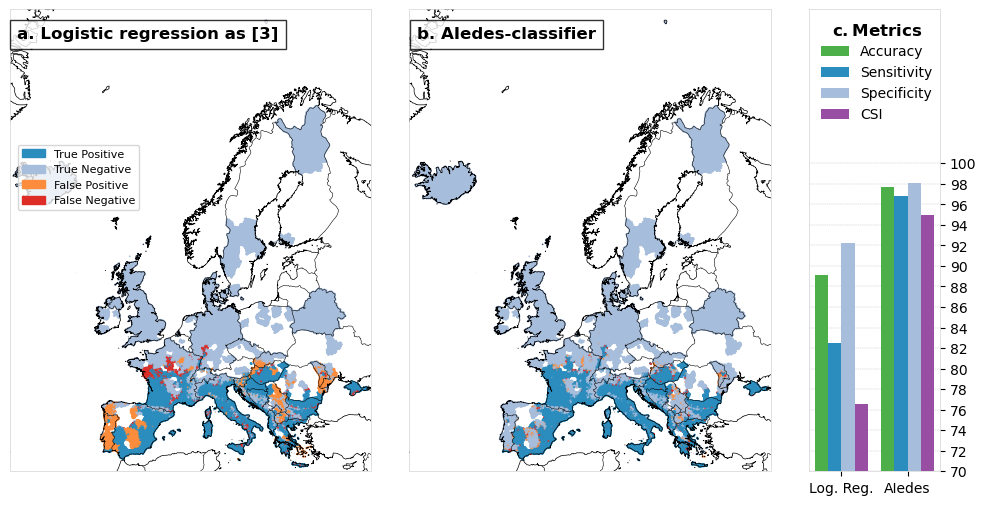

In [30]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# Prepare GeoDataFrame
df_Presence_Absence = gpd.GeoDataFrame(
    df_Presence_Absence.copy(), 
    geometry='geometry', 
    crs='EPSG:4326'
)

# Define categories and colors
categories = ['True Positive', 'True Negative', 'False Positive', 'False Negative']
colors = ['#2b8cbe', '#a6bddb', '#fd8d3c', '#de2d26']
colormap = ListedColormap(colors)

# Calculate common extent for both maps
minx, miny, maxx, maxy = df_Presence_Absence.total_bounds
pad = 0.5
extent = [minx - pad, maxx + pad, miny - pad, maxy + pad]

# Create figure with two maps and a bar chart
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[3, 3, 1], wspace=0.02)
axes = [fig.add_subplot(gs[0, i], projection=ccrs.Mercator()) for i in range(2)]
ax_bar = fig.add_subplot(gs[0, 2])

# Configure map axes
for ax in axes:
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_anchor('W')
    ax.coastlines('10m', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor='white')


def plot_predictions(df, ax, markersize=2, alpha=0.8):
    """Plot prediction results on map"""
    df_valid = df[df.geometry.is_valid].copy()
    # sample if too large
    if df_valid.shape[0] > 50000:
        df_valid = df_valid.sample(n=100000, random_state=1)
    # Classify results
    df_valid['results'] = np.select(
        [
            (df_valid['Presence_Absence'] == 1) & (df_valid['predicted'] == 1),
            (df_valid['Presence_Absence'] == 0) & (df_valid['predicted'] == 0),
            (df_valid['Presence_Absence'] == 0) & (df_valid['predicted'] == 1),
            (df_valid['Presence_Absence'] == 1) & (df_valid['predicted'] == 0),
        ],
        categories,
        default='NA'
    )
    
    # Map categories to numeric values for colormap
    cat_to_idx = {c: i for i, c in enumerate(categories)}
    cvals = df_valid['results'].map(cat_to_idx).to_numpy()
    
    # Use scatter with proper transform (same as first version)
    ax.scatter(
        df_valid.geometry.x.to_numpy(),
        df_valid.geometry.y.to_numpy(),
        c=cvals,
        s=markersize,
        cmap=colormap,
        alpha=alpha,
        edgecolors='none',
        transform=ccrs.PlateCarree()
    )


# Model 1: Logistic Regression (no hidden layers)
model_info_lr = res_df[res_df["hidden_layers"] == "[]"]
net_lr = model_info_lr["model"].values[0][0]

df_lr = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_lr["predicted_estim_risk"] = compute_suitability_index(EstimRisk, test_loader_order_4Bio).numpy()
df_lr["predicted"] = df_lr["predicted_estim_risk"] > 0.5

plot_predictions(df_lr, axes[0])

axes[0].text(
    0.02, 0.93, "a. Logistic regression as [3]",
    transform=axes[0].transAxes,
    fontsize=12, fontweight='bold', 
    va='bottom', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=5)
)

# Model 2: Neural Network with hidden layers
model_info_nn = res_df[res_df["hidden_layers"] == "[40, 40, 40]"]
model_info_nn = model_info_nn[model_info_nn["input"] == "4Bio"]
net_nn = model_info_nn["model"].values[0][0]

df_nn = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_nn["predicted_estim_risk"] = compute_suitability_index(net_nn, test_loader_order_4Bio_nn).numpy()
df_nn["predicted"] = df_nn["predicted_estim_risk"] > 0.5

plot_predictions(df_nn, axes[1])

axes[1].text(
    0.02, 0.93, "b. AIedes-classifier",
    transform=axes[1].transAxes,
    fontsize=12, fontweight='bold', 
    va='bottom', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=5)
)

# Multi-metric bar chart
x_labels = ['Log. Reg.', 'AIedes']
x = np.arange(len(x_labels))
width = 0.2

# Extract metric values
accuracy_values = np.array([
    model_info_lr["MEAN_ACC_test"].values[0],
    model_info_nn["MEAN_ACC_test"].values[0]
]) 

tpr_values = np.array([
    model_info_lr["MEAN_TPR_test"].values[0],
    model_info_nn["MEAN_TPR_test"].values[0]
]) * 100

tnr_values = np.array([
    model_info_lr["MEAN_TNR_test"].values[0],
    model_info_nn["MEAN_TNR_test"].values[0]
]) * 100

csi_values = np.array([
    model_info_lr["CSI_test"].values[0],
    model_info_nn["CSI_test"].values[0]
]) * 100

# Plot bars with distinct colors
ax_bar.bar(x - width, accuracy_values, width, label='Accuracy', color="#4daf4a")
ax_bar.bar(x, tpr_values, width, label='Sensitivity', color='#2b8cbe')
ax_bar.bar(x + width, tnr_values, width, label='Specificity', color='#a6bddb')
ax_bar.bar(x + 2 * width, csi_values, width, label='CSI', color="#984ea3")

# Format bar chart
ax_bar.yaxis.set_label_position("right")
ax_bar.yaxis.set_ticks_position("right")
ax_bar.set_xticks(x+0.1)
ax_bar.set_xticklabels(x_labels)
ax_bar.set_ylim(70, 115)
ax_bar.set_yticks([70, 80, 90, 100])

# Format bar chart
ax_bar.yaxis.set_label_position("right")
ax_bar.yaxis.set_ticks_position("right")
ax_bar.set_xticks(x+0.1)
ax_bar.set_xticklabels(x_labels)
ax_bar.set_ylim(70, 115)
ax_bar.set_yticks([70, 80, 90, 100])

# Add grid from 70 to 100 with spacing of 5
ax_bar.set_axisbelow(True)
ax_bar.grid(axis='y', linestyle='--', alpha=0.5, color='gray', linewidth=0.3)
ax_bar.set_yticks(np.arange(70, 101, 2))  # Grid lines every 5 units from 70 to 100


ax_bar.legend(
    loc='upper left', 
    fontsize=10, 
    frameon=False, 
    title=r'$\bf{c. Metrics}$', 
    title_fontsize='12'
)

# Add legend for map categories
patches = [mpatches.Patch(color=c, label=cat) for c, cat in zip(colors, categories)]
fig.legend(
    handles=patches, 
    bbox_to_anchor=(0.127, 0.6), 
    loc='center left', 
    frameon=True, 
    fontsize=8
)

for spine in axes[0].spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(0.5)

for spine in axes[1].spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(0.5)

for spine in ax_bar.spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(0.5)
    
# Save figure
fig.savefig("./comparison_lg_aiedes_worldClim.png", dpi=400, bbox_inches='tight')

plt.show()